**Obesity Level Prediction Model Based on Eating Habits and Physical Condition**

*Introduction*

In this project, we developed a multiclass classification model capable of predicting an individual's obesity level (e.g., "Normal Weight," "Type I Obesity," "Level II Overweight") using data related to their eating habits, physical activity, and demographic characteristics. The goal is not only to build an accurate predictor but also to understand how factors such as caloric intake, frequency of physical activity, and adherence to a balanced diet influence obesity risk.

***PATH DIR, Necessary Libraries and Load Data***

In [130]:
# Paths and config
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pycaret.classification import *

# Avoid warnings
import warnings
warnings.filterwarnings('ignore')

# Load Data
PATH = os.getcwd()
DIR_DATA = os.path.join(PATH, 'data')
filename = os.path.join(DIR_DATA, 'ObesityDataSet.csv')
df = pd.read_csv(filename, encoding='latin-1')

# Quick Check
print("Sample dataset:")
display(df.head(3))
print("\nNull values:", df.isnull().sum().sum())

Sample dataset:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight



Null values: 0


In [131]:
# Describe the dataset
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [132]:
# Data summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

***Variable Description***

*Numeric Variables*:
- `Age`: Age in years.
- `Height`: Height in meters.
- `Weight`: Weight in kg.
- `FCVC`: Frequency of vegetable consumption (1: Never, 3: Always).
- `NCP`: Number of main meals per day.
- `CH2O`: Daily water consumption (in liters).
- `FAF`: Frequency of physical activity (0: Sedentary, 3: Active).
- `TUE`: Time using electronic devices (hours/day).

*Categorical Variables*:
- `Gender`: Gender (Male/Female).
- `family_history_with_overweight`: Family history of overweight (yes/no).
- `FAVC`: Frequent consumption of high-calorie foods (yes/no). - `CAEC`: Alcohol consumption (Sometimes/Frequently/Always).
- `SMOKE`: Smoker (yes/no).
- `SCC`: Calorie monitoring (yes/no).
- `CALC`: Alcohol consumption (no/Sometimes/Frequently).
- `MTRANS`: Mode of transportation (Public Transportation/Walking/etc.).

*Target*:
- `NObeyesdad`: Obesity level (7 classes: Normal Weight, Overweight Level I, Obesity Type I, etc.).

***Hypothesis Formulation***

*Calorie Intake*: "People with a high frequency of consuming high-calorie foods (FAVC=yes) have a higher likelihood of obesity."

*Physical Activity*: "Higher frequency of physical activity (FAF) is correlated with lower levels of obesity."

*Water and Vegetables*: "Higher consumption of water (CH2O) and vegetables (FCVC) reduces the risk of obesity."

*Combined Factors*: "The combination of a sedentary lifestyle (MTRANS=Automobile) and high alcohol consumption (CALC=Frequently) increases the risk of extreme obesity."

***Exploratory Data Analysis (EDA)***

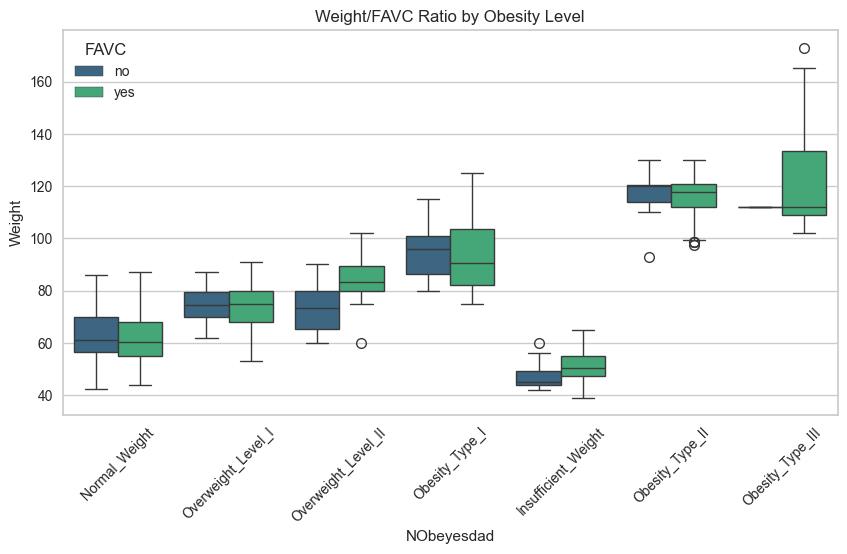

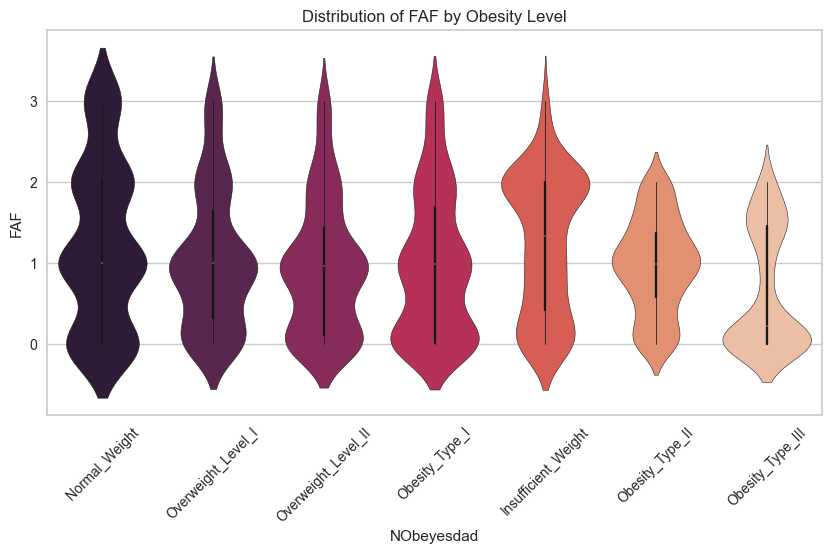

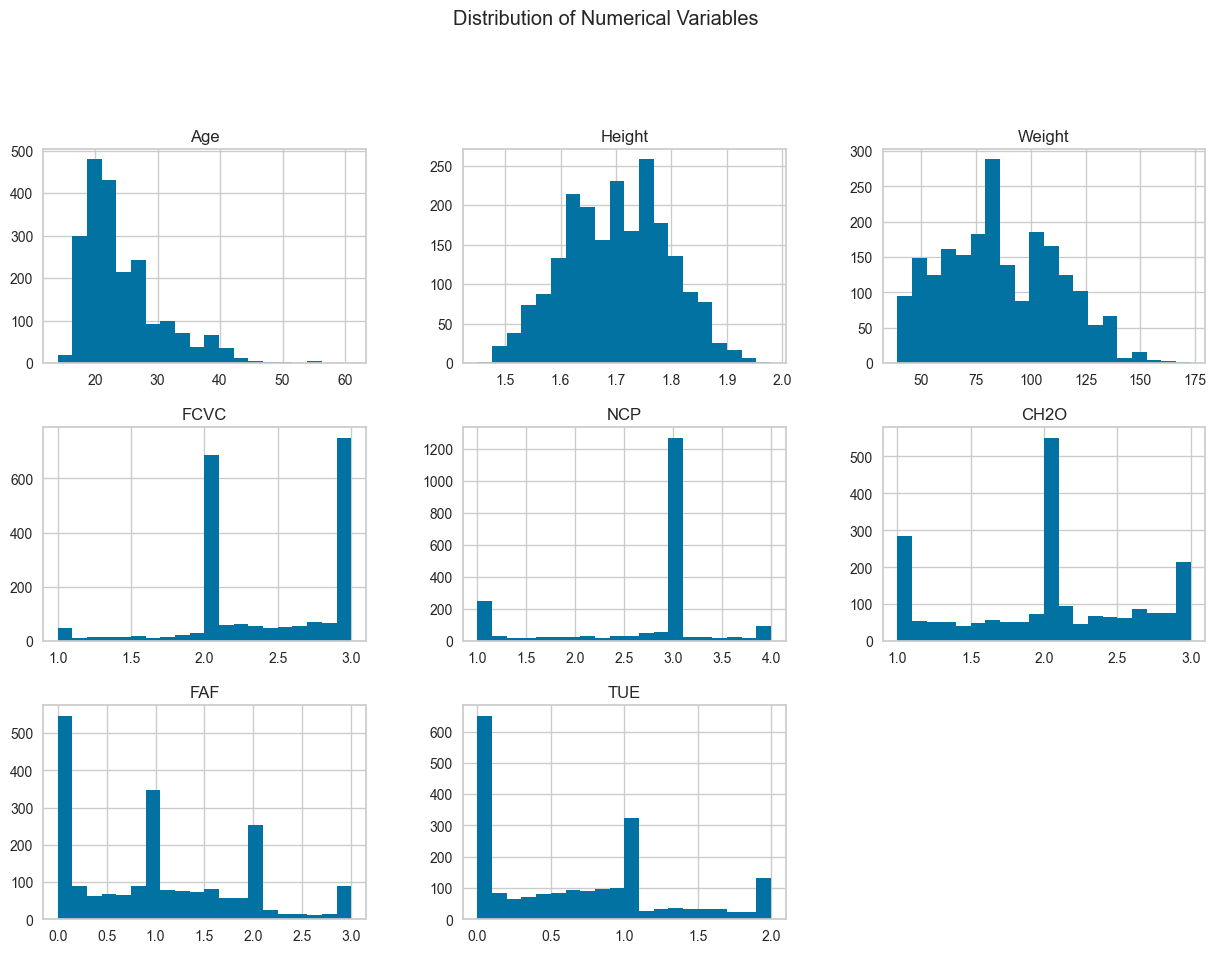

In [133]:
# Hypothesis 1: Caloric intake (FAVC) affects weight
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='NObeyesdad', y='Weight', hue='FAVC', palette='viridis')
plt.title('Weight/FAVC Ratio by Obesity Level')
plt.xticks(rotation=45)
plt.show()

# Hypothesis 2: Physical activity (FAF) vs. obesity
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='NObeyesdad', y='FAF', palette='rocket')
plt.title('Distribution of FAF by Obesity Level')
plt.xticks(rotation=45)
plt.show()

# Numerical variables (simplified)
num_vars = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
df[num_vars].hist(figsize=(15, 10), bins=20)
plt.suptitle('Distribution of Numerical Variables', y=1.02)
plt.show()

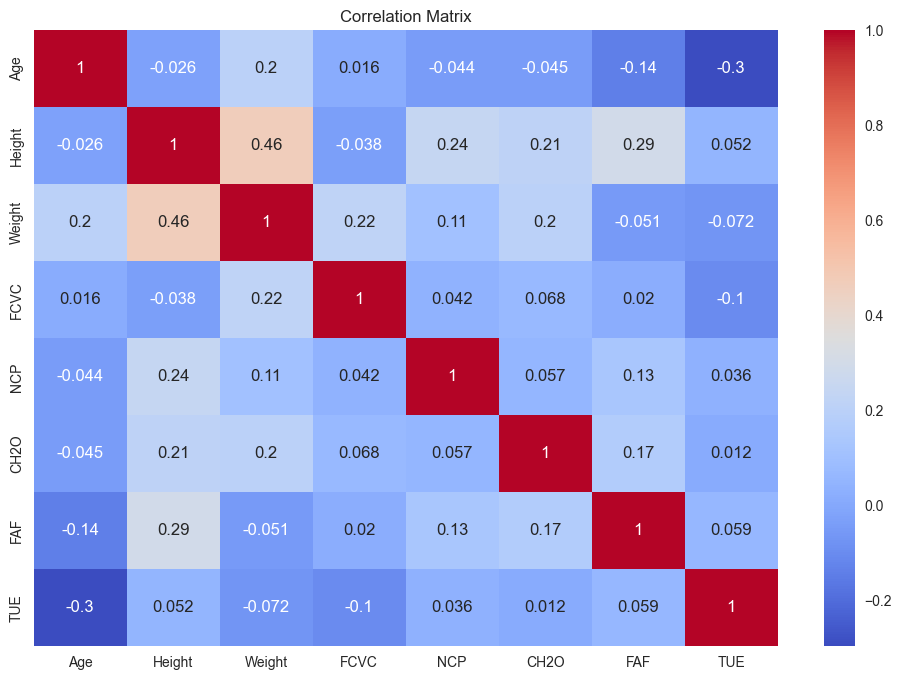

In [134]:
# Correlation matrix (numeric variables only)
corr_matrix = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

***PyCaret Preprocessing and Configuration***

In [135]:
# Initialize the PyCaret setup
setup_clf = setup(
    data=df,
    target='NObeyesdad',
    train_size=0.8,
    session_id=42,
    normalize=True,
    remove_outliers=True,
    fix_imbalance=True,    # SMOTE
    categorical_features=['Gender','family_history_with_overweight','FAVC','CAEC','SMOKE','SCC','CALC','MTRANS'],
    numeric_features=['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE'],
    data_split_stratify=True,
    feature_selection=True,
    feature_selection_method='classic',
    verbose=False
)

In [136]:
# Comparing models (hypothesis-based)
best_model = compare_models(
    include=['lr', 'svm'],
    sort='Accuracy',
    n_select=1
)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.8637,0.0000,0.8637,0.8749,0.8624,0.8409,0.8429,4.0160
svm,SVM - Linear Kernel,0.5480,0.0000,0.5480,0.5228,0.5034,0.4715,0.4926,0.5080


***Training and Hyperparameter Tuning***

In [137]:
# Final model (logistic regression)
model = create_model('lr', cross_validation=True)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8876,0.0000,0.8876,0.8904,0.8854,0.8686,0.8697
1,0.8935,0.0000,0.8935,0.9007,0.8934,0.8756,0.8768
2,0.8521,0.0000,0.8521,0.8632,0.8536,0.8274,0.8287
3,0.8698,0.0000,0.8698,0.8733,0.8683,0.8480,0.8491
4,0.8757,0.0000,0.8757,0.8877,0.8732,0.8549,0.8571
5,0.8580,0.0000,0.8580,0.8763,0.8543,0.8342,0.8375
6,0.8757,0.0000,0.8757,0.8851,0.8716,0.8550,0.8574
7,0.8166,0.0000,0.8166,0.8431,0.8185,0.7859,0.7893
8,0.8393,0.0000,0.8393,0.8550,0.8367,0.8124,0.8157


In [138]:
# Tuning hyperparameters with random search
tuned_model = tune_model(
    model,
    optimize='Accuracy',
    search_library='scikit-learn',
    search_algorithm='random',
    n_iter=50
)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9231,0.0000,0.9231,0.9228,0.9222,0.9101,0.9104
1,0.9349,0.0000,0.9349,0.9356,0.9347,0.9240,0.9241
2,0.9290,0.0000,0.9290,0.9295,0.9290,0.9171,0.9171
3,0.9349,0.0000,0.9349,0.9401,0.9355,0.9240,0.9247
4,0.9231,0.0000,0.9231,0.9315,0.9219,0.9102,0.9118
5,0.9112,0.0000,0.9112,0.9174,0.9099,0.8963,0.8976
6,0.9112,0.0000,0.9112,0.9187,0.9112,0.8964,0.8977
7,0.9408,0.0000,0.9408,0.9454,0.9416,0.9309,0.9314
8,0.9286,0.0000,0.9286,0.9377,0.9284,0.9166,0.9182


Fitting 10 folds for each of 50 candidates, totalling 500 fits


In [139]:
# Evaluate metrics on the test set
holdout_pred = predict_model(tuned_model)
print(classification_report(holdout_pred['NObeyesdad'], holdout_pred['prediction_label']))

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9314,0.9970,0.9314,0.9354,0.9312,0.9199,0.9206


                     precision    recall  f1-score   support

Insufficient_Weight       0.90      1.00      0.95        54
      Normal_Weight       0.98      0.83      0.90        58
     Obesity_Type_I       0.96      0.97      0.96        70
    Obesity_Type_II       0.93      0.95      0.94        60
   Obesity_Type_III       0.98      0.94      0.96        65
 Overweight_Level_I       0.84      0.97      0.90        58
Overweight_Level_II       0.94      0.86      0.90        58

           accuracy                           0.93       423
          macro avg       0.93      0.93      0.93       423
       weighted avg       0.94      0.93      0.93       423



***Model Interpretation***

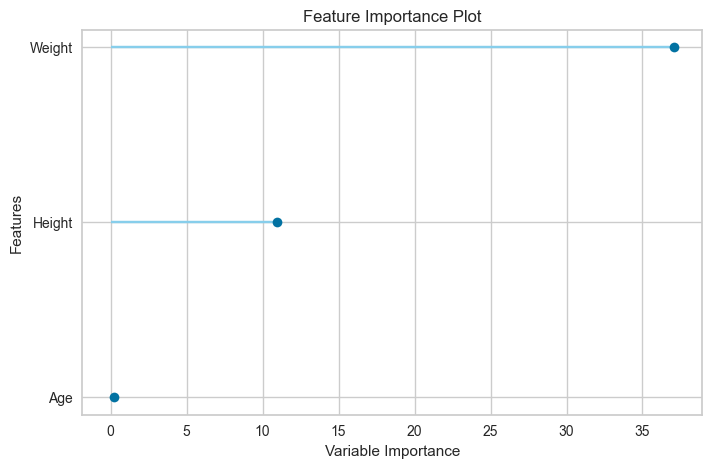

In [140]:
# Feature Importance Chart
plot_model(tuned_model, plot='feature')

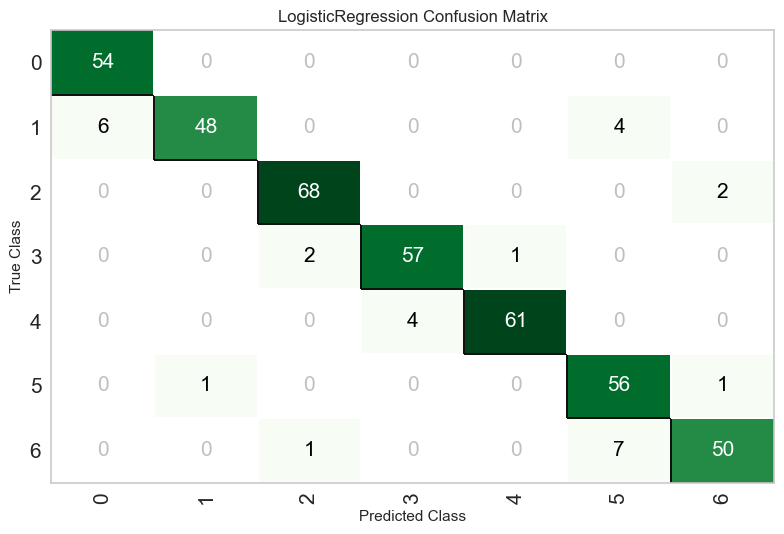

In [141]:
# Confusion Matrix
plot_model(tuned_model, plot='confusion_matrix')

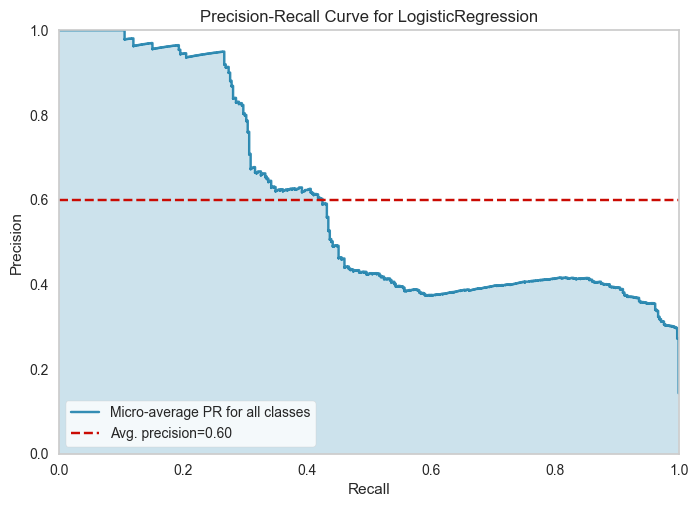

In [142]:
# Precision-Recall curve
plot_model(tuned_model, plot='pr')

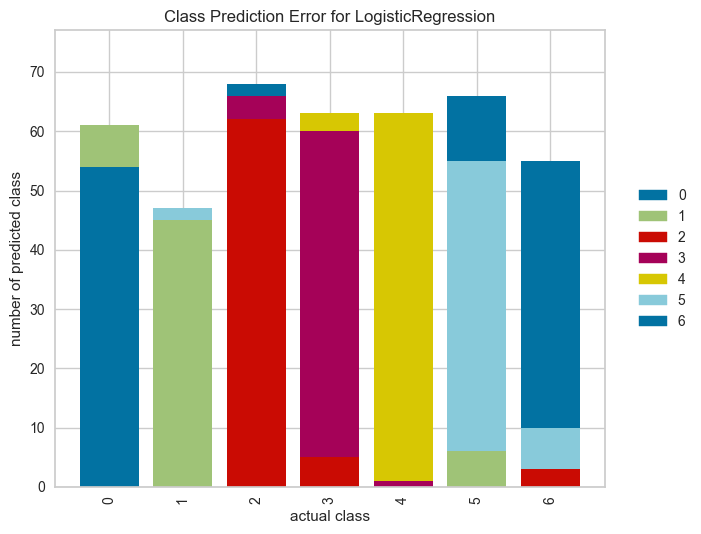

In [143]:
# Error graph of the trained model.
plot_model(model, plot='error')

In [144]:
# Finalize the model with all the data (train + test)
final_model = finalize_model(tuned_model)

# Save model and pipeline
save_model(final_model, 'obesity_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Age', 'Height', 'Weight', 'FCVC',
                                              'NCP', 'CH2O', 'FAF', 'TUE'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_...
                                                                 importance_getter='auto',
                                                                 max_features=3,
                                   

In [145]:
# Cross-validation results
cv_results = pull()
print("Cross-Validation Results (PyCaret):")
display(cv_results)

Cross-Validation Results (PyCaret):


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9314,0.997,0.9314,0.9354,0.9312,0.9199,0.9206


In [146]:
# Load and predict with new data
loaded_model = load_model('obesity_model')
new_data = pd.DataFrame([{
    'Gender': 'Female', 'Age': 35, 'Height': 1.65, 'Weight': 90,
    'family_history_with_overweight': 'yes', 'FAVC': 'yes', 'FCVC': 2,
    'NCP': 3, 'CAEC': 'Sometimes', 'SMOKE': 'no', 'CH2O': 1,
    'SCC': 'no', 'FAF': 0, 'TUE': 2, 'CALC': 'Frequently', 'MTRANS': 'Automobile'
}])

predictions = predict_model(loaded_model, data=new_data)
print("\nPrediction for new data:", predictions['prediction_label'][0])

Transformation Pipeline and Model Successfully Loaded



Prediction for new data: Obesity_Type_I
